# TP — Régression Logistique avec Python


## Objectifs pédagogiques

À la fin de ce TP, vous serez capable de :

- Comprendre le principe de la régression logistique
- Préparer des données pour un problème de classification
- Standardiser des variables numériques
- Entraîner un modèle de classification avec Scikit-Learn
- Évaluer les performances d’un modèle avec la métrique Log Loss
- Interpréter les coefficients d’un modèle de régression logistique



## Contexte

Une entreprise de télécommunications souhaite prédire quels clients risquent de quitter ses services (`churn`).

L’objectif est de construire un modèle de classification capable de prédire si un client va quitter l’entreprise ou non.


## 1. Import des bibliothèques

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import log_loss, accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


## 2. Chargement du dataset

In [ ]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"

churn_df = pd.read_csv(url)

churn_df.head()


,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


## 3. Exploration des données

In [ ]:
# Dimensions du dataset
print(churn_df.shape)

# Types des colonnes
print(churn_df.dtypes)

# Valeurs manquantes
print(churn_df.isnull().sum())


(200, 28)
tenure      float64
age         float64
address     float64
income      float64
ed          float64
employ      float64
equip       float64
callcard    float64
wireless    float64
longmon     float64
tollmon     float64
equipmon    float64
cardmon     float64
wiremon     float64
longten     float64
tollten     float64
cardten     float64
voice       float64
pager       float64
internet    float64
callwait    float64
confer      float64
ebill       float64
loglong     float64
logtoll     float64
lninc       float64
custcat     float64
churn       float64
dtype: object
tenure      0
age         0
address     0
income      0
ed          0
employ      0
equip       0
callcard    0
wireless    0
longmon     0
tollmon     0
equipmon    0
cardmon     0
wiremon     0
longten     0
tollten     0
cardten     0
voice       0
pager       0
internet    0
callwait    0
confer      0
ebill       0
loglong     0
logtoll     0
lninc       0
custcat     0
churn       0
dtype: int64



## 4. Préparation des données

Nous allons utiliser les variables suivantes :

- tenure
- age
- address
- income
- ed
- employ
- equip

La variable cible sera :

- churn


In [ ]:
churn_df = churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]

# Conversion de la cible en entier
churn_df['churn'] = churn_df['churn'].astype('int')

churn_df.head()


,tenure,age,address,income,ed,employ,equip,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,0


## 5. Séparation des variables X et y

In [ ]:
X = np.asarray(churn_df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']])

y = np.asarray(churn_df['churn'])

print(X[:5])
print(y[:5])


[[ 11.  33.   7. 136.   5.   5.   0.]
 [ 33.  33.  12.  33.   2.   0.   0.]
 [ 23.  30.   9.  30.   1.   2.   0.]
 [ 38.  35.   5.  76.   2.  10.   1.]
 [  7.  35.  14.  80.   2.  15.   0.]]
[1 1 0 0 0]



## 6. Standardisation des données

La standardisation permet de mettre toutes les variables à la même échelle afin d’améliorer les performances du modèle.


In [ ]:
X_norm = StandardScaler().fit(X).transform(X)

X_norm[:5]


array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841, -0.85972695],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497, -0.85972695],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635, -0.85972695],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185,  1.16316   ],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472, -0.85972695]])

## 7. Séparation des données d'entraînement et de test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm,
    y,
    test_size=0.2,
    random_state=4
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)


Train : (160, 7)
Test : (40, 7)


## 8. Construction du modèle de Régression Logistique

In [ ]:
LR = LogisticRegression()

LR.fit(X_train, y_train)


LogisticRegression()

## 9. Prédictions

In [ ]:
yhat = LR.predict(X_test)

yhat[:10]


array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0])

## 10. Probabilités de prédiction

In [ ]:
yhat_prob = LR.predict_proba(X_test)

yhat_prob[:10]


array([[0.74643946, 0.25356054],
       [0.92667894, 0.07332106],
       [0.83442627, 0.16557373],
       [0.94600618, 0.05399382],
       [0.84325532, 0.15674468],
       [0.71448367, 0.28551633],
       [0.77076426, 0.22923574],
       [0.90955642, 0.09044358],
       [0.26152115, 0.73847885],
       [0.94900731, 0.05099269]])


Chaque ligne contient :

- Colonne 0 → probabilité d’appartenir à la classe 0
- Colonne 1 → probabilité d’appartenir à la classe 1


## 11. Importance des variables

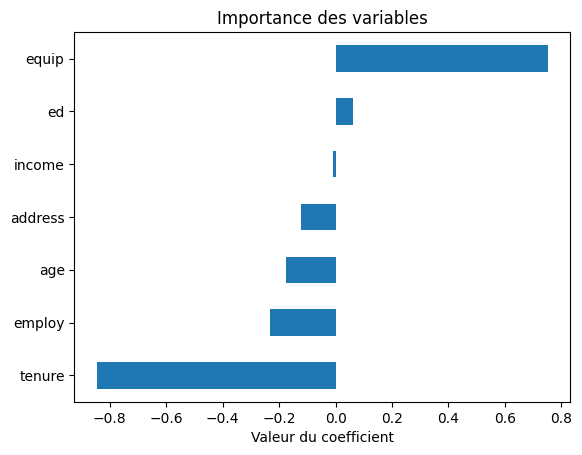

In [ ]:
coefficients = pd.Series(
    LR.coef_[0],
    index=['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip']
)

coefficients.sort_values().plot(kind='barh')

plt.title("Importance des variables")
plt.xlabel("Valeur du coefficient")

plt.show()



### Interprétation

- Un coefficient positif augmente la probabilité d’appartenir à la classe 1
- Un coefficient négatif réduit cette probabilité
- Plus la valeur absolue est grande, plus la variable influence la prédiction


## 12. Évaluation du modèle

In [ ]:
print("Accuracy :", accuracy_score(y_test, yhat))

print()

print("Log Loss :", log_loss(y_test, yhat_prob))


Accuracy : 0.725

Log Loss : 0.6257718410257235


## 13. Matrice de confusion

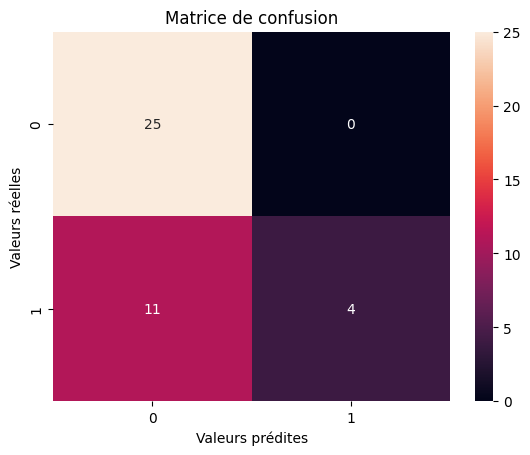

In [ ]:
cm = confusion_matrix(y_test, yhat)

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion")

plt.show()


## 14. Rapport de classification

In [ ]:
print(classification_report(y_test, yhat))


              precision    recall  f1-score   support

           0       0.69      1.00      0.82        25
           1       1.00      0.27      0.42        15

    accuracy                           0.72        40
   macro avg       0.85      0.63      0.62        40
weighted avg       0.81      0.72      0.67        40

